# nb19 -- fluid adequacy judged the way the data judge it: error vs signal on P/P_LCDM

Abellan et al. 2021 justify their fluid approximation by comparing fluid vs exact on the
**observable residuals relative to LCDM** (their Figs 14-15), not on absolute P(k). The logic:
the data constrain the departure from LCDM, so to first order the parameter bias is the fluid
error projected onto the signal -- adequacy means
`|P_fluid - P_exact| << |P_exact - P_LCDM|` on the scales carrying data weight, and both << data errors.

This notebook makes that quantitative for the current accDM fitted-formula fluid (nb18 mode-3):

1. **Shapes**: `P/P_LCDM` for exact vs fluid, overlaid per (f, eta) corner (the paper's visual).
2. **Error-to-signal**: `eps(k) = (P_fluid - P_exact) / (P_exact - P_LCDM)`, masked where the
   signal is below `SIGNAL_FLOOR` (the onset region makes the ratio meaningless).
3. **Broadband**: the same ratio at the sigma8 level (spikes can integrate away in S8-type
   measures while still poisoning full-shape likelihoods -- report both).
4. **Degeneracy check**: least-squares projection of the fluid error onto finite-difference
   (f, eta) signal templates -- a small error that mimics a parameter shift biases posteriors
   rather than averaging out.

**Decision rules** (evaluate on `K_DATA = [0.05, 1] Mpc^-1`):
- adequate for MCMC if `max|eps| < 10%` and the sigma8-level ratio `< 10%` at every corner;
- if the max is blown only by localized spike/dip pairs but the median is fine, the fluid is
  adequate for broadband (S8) likelihoods and NOT for full-shape ones -- say so explicitly;
- if the projected (delta_f, delta_eta) equivalent bias is comparable to expected posterior
  widths, the fluid fails even if `|eps|` is small.

Defaults below reproduce the configuration of the plot under discussion (2026-07-15):
trigger 0.4, **frozen shear** (`switch_off_shear_acc = 'yes'`). Both are single-knob switches
in the setup cell; rerunning with `SHEAR = 'no'` gives the dynamical-shear (corrected equation)
comparison when that test becomes relevant.

In [ ]:
import os, time, pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from classy import Class
import sys; sys.path.insert(0, '.')
from fluid_closure_helpers import A_eff_of_f

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 200})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3', '#a65628', '#999999', '#e41a1c', '#dede00']

# --- base cosmology (same as nb15-nb18) ---
omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
PREC = {'output': 'mPk', 'P_k_max_1/Mpc': 1.0, 'z_max_pk': 0.0,
        'evolver': 0, 'reionization_z_start_max': 80}

# --- calibration-domain knobs (nb18) ---
KAPPA, A_T, MASS = 6.0, 0.13, 1e16
A_REC = 1.0 / (1.0 + 1090.0)

# --- run matrix: the nb18 Stage-C corners ---
CORNERS = [(0.1, 0.01), (0.1, 0.05), (0.1, 0.2), (0.1, 0.3),  (0.1, 0.4), (0.1, 0.5), (0.3, 0.05), (0.3, 0.5), (0.2, 0.1)]
K_PK    = np.logspace(-3, 0.0, 40)
TRIGGER = 2.0        # abundance-gate threshold of the configuration being judged
SHEAR   = 'no'      # 'yes' = frozen shear (plot under discussion); 'no' = dynamical (corrected eq)
A0_ETA, B_F = 0.5223, 0.0   # current nb18 formula coefficients -- KEEP IN SYNC with nb18 Stage B

# --- adequacy thresholds (decision rules in the markdown above) ---
SIGNAL_FLOOR = 0.005          # mask k where |P_exact/P_LCDM - 1| < 0.5%
K_DATA       = (0.05, 1.0)    # window where S8-type data weight lives
EPS_TARGET   = 0.10           # error-to-signal adequacy target on K_DATA

def q_exact_of_f(f_acc):
    """Converged exact-reference q-grid (memory: accdm-fluid-f-boundary)."""
    return 1001 if f_acc <= 0.1 else 5001

CACHE_DIR = os.path.join('accDM_scans', 'nb19_cache'); os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_TAG = 'adiabatic'   # bump after any params change; exact refs are reusable across TRIGGER/SHEAR
print('setup OK: {} corners, trigger {}, shear_off={}'.format(len(CORNERS), TRIGGER, SHEAR))

setup OK: 9 corners, trigger 1.0, shear_off=no


## Run matrix

One LCDM reference + (exact, fluid) per corner. The LCDM reference keeps the **early-time**
densities identical (uncompensated `omega_cdm0`, same neutrino sector, no acc sector) --
matching how `accdm_params` normalizes the acc runs at recombination, so `P/P_LCDM -> 1` at
low k and the ratio isolates the accDM signal.

The f = 0.3 exact references (q = 5001) are the slow runs. Everything is pickle-cached under
`accDM_scans/nb19_cache/`; exact-run cache entries do not depend on TRIGGER/SHEAR, so toggling
those only recomputes the cheap fluid runs.

In [11]:
def lcdm_params():
    """Reference LCDM: identical early-time densities and neutrino sector, no acc sector."""
    p = dict(base_params); p.update(PREC)
    p.update({'N_ncdm': 1, 'deg_ncdm': '3', 'm_ncdm': '0.02', 'T_ncdm': '0.71611',
              'ncdm_quadrature_strategy': '0', 'ncdm_N_momentum_bins': '15',
              'N_ur': 0.00441, 'gauge': 'synchronous'})
    return p

def accdm_params(f_acc, eta, q_size):
    """Exact-hierarchy accDM params (identical to nb18)."""
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**KAPPA)/(1 + (A_REC/A_T)**KAPPA))**(-1)
    p = dict(base_params); p.update(PREC)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': KAPPA, 'a_t_acc': A_T,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {}'.format(q_size), 'N_ur': 0.00441,
              'background_Nloga': 5001, 'gauge': 'synchronous',
              'get_perturbations_in_current_gauge': 'yes',
              'ncdm_fluid_trigger_tau_over_tau_k': 25,
              'ncdm_fluid_approximation': 3})           # 3 = none (exact hierarchy)
    return p

def fluid_params(f_acc, eta, trigger=TRIGGER, shear_off=SHEAR):
    """Mode-3 fitted-formula fluid (nb18), with the trigger/shear knobs exposed."""
    p = accdm_params(f_acc, eta, q_exact_of_f(f_acc))
    p['ncdm_fluid_approximation'] = 2
    p['ncdm_fluid_trigger_rho_accDM_over_rho_dcdm'] = trigger
    p['switch_off_shear_acc'] = shear_off
    p['ncdm_ceff2_mode'] = 3
    p['ncdm_ceff2_eta_A'] = float(A_eff_of_f(f_acc, A0_ETA, B_F))
    return p

def run_pk(params, tag):
    """Cached CLASS run -> dict(pk on K_PK, sigma8, seconds). Bracketing prints so a
    long run looks different from a hung one."""
    cache_file = os.path.join(CACHE_DIR, '{}_{}.pkl'.format(CACHE_TAG, tag))
    print(cache_file)
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as fh:
            rec = pickle.load(fh)
        print('[cache] {:34s} ({:.0f} s when computed)'.format(tag, rec['seconds']))
        return rec
    print('[run  ] {:34s} ...'.format(tag), flush=True)
    t_start = time.time()
    cosmo = Class(); cosmo.set(params); cosmo.compute()
    pk_values = np.array([cosmo.pk(k_value, 0.0) for k_value in K_PK])
    rec = {'pk': pk_values, 'sigma8': cosmo.sigma8(), 'seconds': time.time() - t_start}
    cosmo.struct_cleanup(); cosmo.empty()
    with open(cache_file, 'wb') as fh:
        pickle.dump(rec, fh)
    print('[done ] {:34s} {:.0f} s  sigma8 = {:.5f}'.format(tag, rec['seconds'], rec['sigma8']))
    return rec

In [12]:
runs = {}
runs['lcdm'] = run_pk(lcdm_params(), 'lcdm')
for f_acc, eta in tqdm(CORNERS, desc='corners'):
    corner_tag = 'f{:g}_eta{:g}'.format(f_acc, eta)
    runs[('exact', f_acc, eta)] = run_pk(
        accdm_params(f_acc, eta, q_exact_of_f(f_acc)), 'exact_' + corner_tag)
    runs[('fluid', f_acc, eta)] = run_pk(
        fluid_params(f_acc, eta), 'fluid_t{:g}_shear{}_{}'.format(TRIGGER, SHEAR, corner_tag))
print('all runs in hand')

accDM_scans/nb19_cache/adiabatic_lcdm.pkl
[cache] lcdm                               (1 s when computed)


corners: 100%|██████████| 9/9 [00:00<00:00, 177.64it/s]

accDM_scans/nb19_cache/adiabatic_exact_f0.1_eta0.01.pkl
[cache] exact_f0.1_eta0.01                 (1892 s when computed)
accDM_scans/nb19_cache/adiabatic_fluid_t1_shearno_f0.1_eta0.01.pkl
[cache] fluid_t1_shearno_f0.1_eta0.01      (2607 s when computed)
accDM_scans/nb19_cache/adiabatic_exact_f0.1_eta0.05.pkl
[cache] exact_f0.1_eta0.05                 (7668 s when computed)
accDM_scans/nb19_cache/adiabatic_fluid_t1_shearno_f0.1_eta0.05.pkl
[cache] fluid_t1_shearno_f0.1_eta0.05      (908 s when computed)
accDM_scans/nb19_cache/adiabatic_exact_f0.1_eta0.2.pkl
[cache] exact_f0.1_eta0.2                  (3148 s when computed)
accDM_scans/nb19_cache/adiabatic_fluid_t1_shearno_f0.1_eta0.2.pkl
[cache] fluid_t1_shearno_f0.1_eta0.2       (2691 s when computed)
accDM_scans/nb19_cache/adiabatic_exact_f0.1_eta0.3.pkl
[cache] exact_f0.1_eta0.3                  (3300 s when computed)
accDM_scans/nb19_cache/adiabatic_fluid_t1_shearno_f0.1_eta0.3.pkl
[cache] fluid_t1_shearno_f0.1_eta0.3       (2609 s 

## 1. Signal shapes: P/P_LCDM, exact (solid) vs fluid (dashed)

The paper's visual. The lower panel is the familiar `P_fluid/P_exact` for cross-reference with
the existing validation plots -- same information, different denominator. What to look for in
the top panel: whether the dashed curve tracks the *shape* of the suppression (onset scale,
depth, slope), because that shape is what constrains (f, eta, trigger) in a fit.

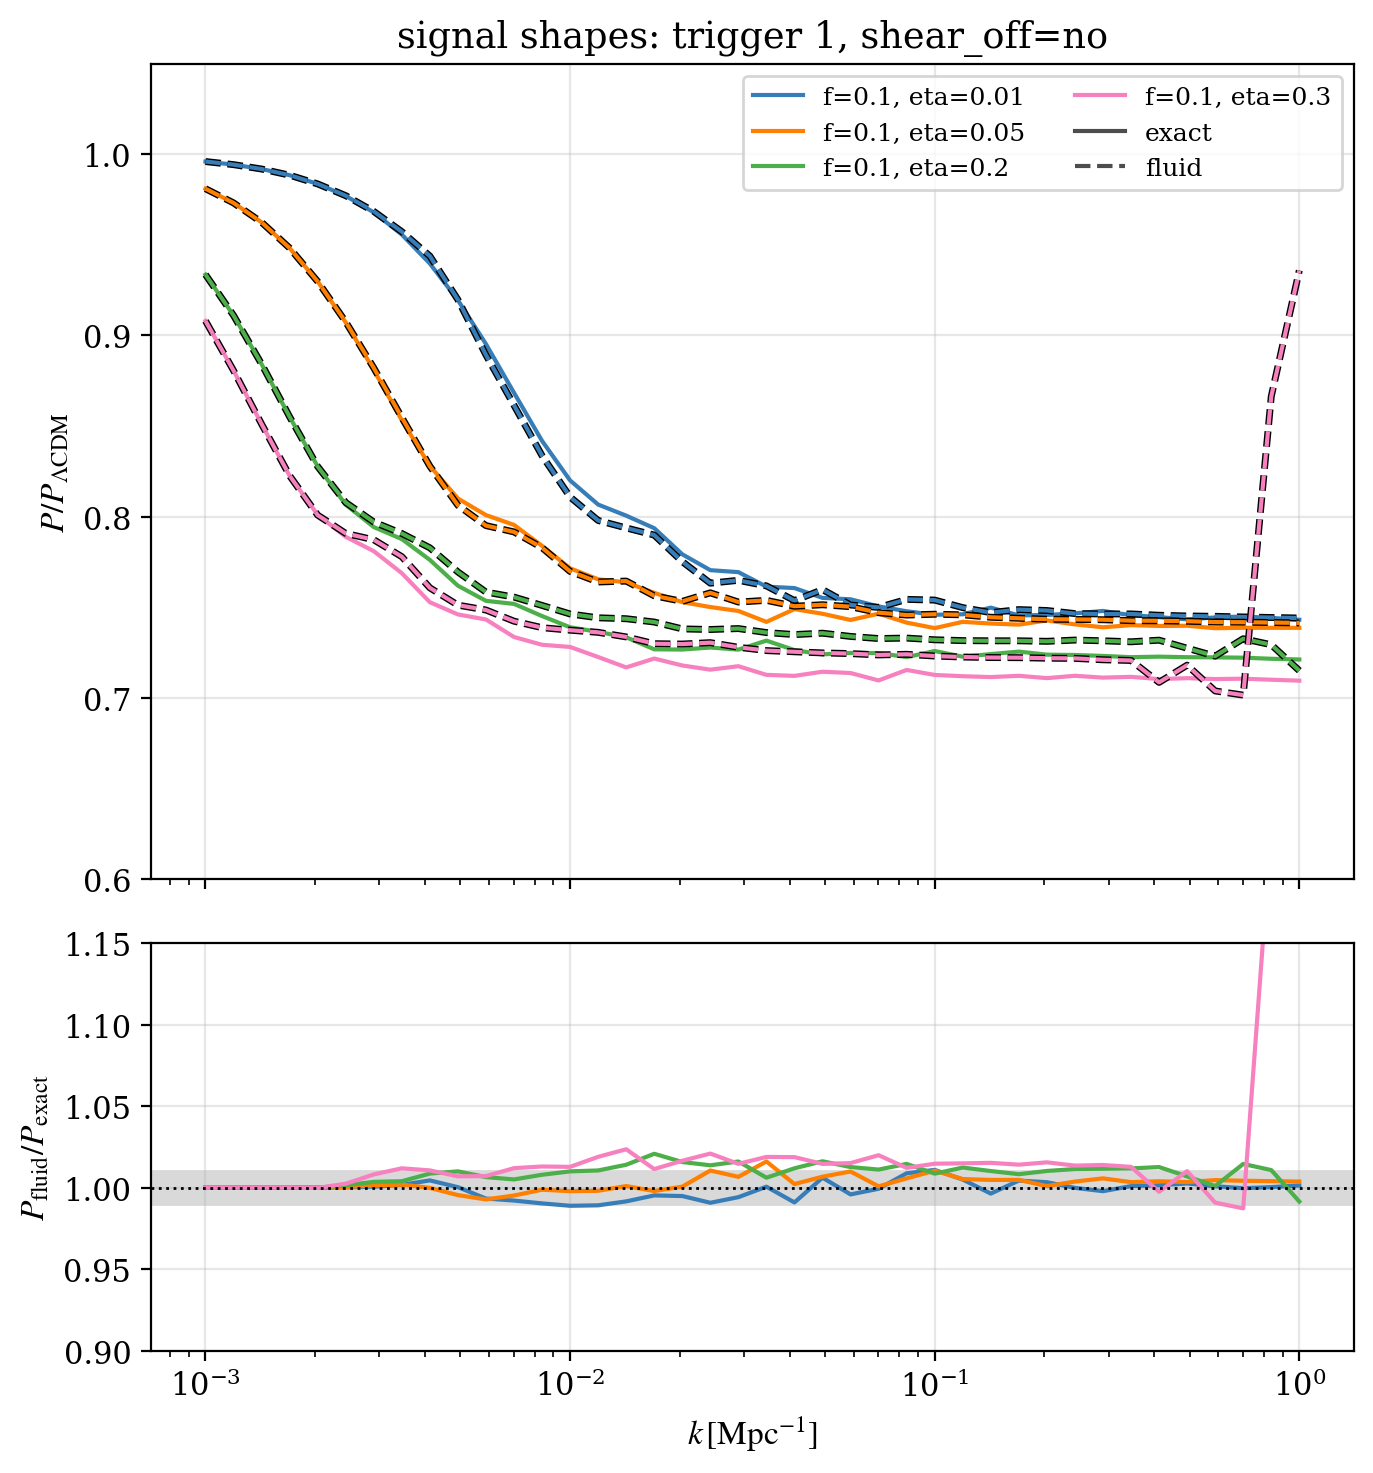

In [36]:
from matplotlib import patheffects as pe

pk_lcdm = runs['lcdm']['pk']

fig, (ax_shape, ax_ratio) = plt.subplots(
    2, 1, figsize=(7.0, 7.5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
for color, (f_acc, eta) in zip(qual_colors, CORNERS):
    shape_exact = runs[('exact', f_acc, eta)]['pk'] / pk_lcdm
    shape_fluid = runs[('fluid', f_acc, eta)]['pk'] / pk_lcdm
    ax_shape.plot(K_PK, shape_exact, color=color, label='f={:g}, eta={:g}'.format(f_acc, eta))
    ax_shape.plot(K_PK, shape_fluid, color=color, ls='--', path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
    ax_ratio.plot(K_PK, shape_fluid/shape_exact, color=color)
ax_shape.plot([], [], color='0.3', ls='-', label='exact')
ax_shape.plot([], [], color='0.3', ls='--', label='fluid')
ax_shape.set_xscale('log'); ax_shape.grid(alpha=0.3)
ax_shape.set_ylabel(r'$P/P_{\Lambda\mathrm{CDM}}$')
ax_shape.legend(ncol=2)
ax_shape.set_ylim(0.6, 1.05)
ax_shape.set_title('signal shapes: trigger {:g}, shear_off={}'.format(TRIGGER, SHEAR))
ax_ratio.axhspan(0.99, 1.01, color='0.85', label=r'$\pm 1\%$')
ax_ratio.axhline(1.0, color='k', ls=':', lw=1)
ax_ratio.set_xscale('log'); ax_ratio.set_ylim(0.9, 1.15); ax_ratio.grid(alpha=0.3)
ax_ratio.set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
ax_ratio.set_ylabel(r'$P_\mathrm{fluid}/P_\mathrm{exact}$')
plt.tight_layout(); plt.show()

## 2. Error-to-signal: eps(k) = (P_fluid - P_exact) / (P_exact - P_LCDM)

This is the metric the shapes argument actually relies on. Masked (gaps in the curves) where
the signal is below `SIGNAL_FLOOR` -- there the model predicts ~nothing, so the fluid cannot
bias anything regardless of its relative error. The summary table scores `|eps|` on the data
window `K_DATA` only; max and median are reported separately because a localized spike/dip
pair (phase-shift signature) blows the max while leaving broadband measures intact.

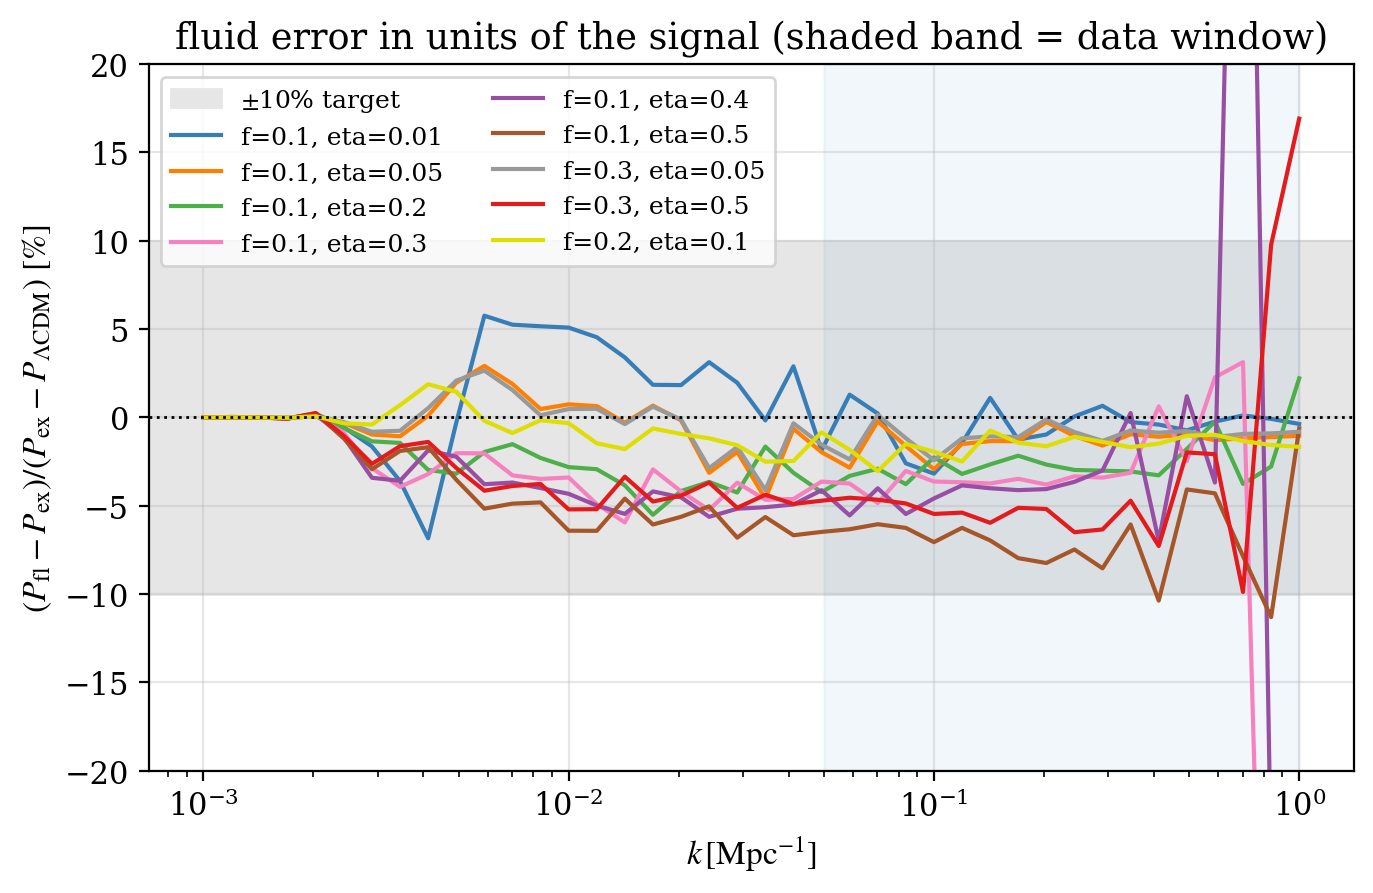

|error/signal| on K_DATA = [0.05, 1] Mpc^-1  (target max < 10%):
  f     eta    max|eps|   median|eps|   verdict
   0.1  0.01      3.2%       0.7%      PASS
   0.1  0.05      2.9%       1.2%      PASS
   0.1   0.2      3.8%       2.9%      PASS
   0.1   0.3     77.9%       3.5%      broadband-only
   0.1   0.4    187.5%       4.1%      broadband-only
   0.1   0.5     11.3%       7.0%      broadband-only
   0.3  0.05      2.4%       0.9%      PASS
   0.3   0.5     16.9%       5.4%      broadband-only
   0.2   0.1      3.0%       1.5%      PASS


In [14]:
k_data_mask = (K_PK >= K_DATA[0]) & (K_PK <= K_DATA[1])
summary_rows = []

fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.axhspan(-100*EPS_TARGET, 100*EPS_TARGET, color='0.9',
           label=r'$\pm${:.0f}% target'.format(100*EPS_TARGET))
for color, (f_acc, eta) in zip(qual_colors, CORNERS):
    pk_exact = runs[('exact', f_acc, eta)]['pk']
    pk_fluid = runs[('fluid', f_acc, eta)]['pk']
    signal_absolute = pk_exact - pk_lcdm
    signal_relative = signal_absolute / pk_lcdm
    masked_signal = np.where(np.abs(signal_relative) > SIGNAL_FLOOR, signal_absolute, np.nan)
    error_to_signal = (pk_fluid - pk_exact) / masked_signal
    ax.plot(K_PK, 100*error_to_signal, color=color,
            label='f={:g}, eta={:g}'.format(f_acc, eta))
    eps_window = np.abs(error_to_signal[k_data_mask])
    eps_window = eps_window[np.isfinite(eps_window)]
    summary_rows.append((f_acc, eta,
                         eps_window.max() if eps_window.size else np.nan,
                         np.median(eps_window) if eps_window.size else np.nan))
ax.axhline(0.0, color='k', ls=':', lw=1)
ax.axvspan(K_DATA[0], K_DATA[1], color='tab:blue', alpha=0.06)
ax.set_xscale('log'); ax.set_ylim(-20, 20); ax.grid(alpha=0.3)
ax.set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$(P_\mathrm{fl}-P_\mathrm{ex})/(P_\mathrm{ex}-P_{\Lambda\mathrm{CDM}})\ [\%]$')
ax.set_title('fluid error in units of the signal (shaded band = data window)')
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

print('|error/signal| on K_DATA = [{:g}, {:g}] Mpc^-1  (target max < {:.0%}):'.format(
    K_DATA[0], K_DATA[1], EPS_TARGET))
print('  f     eta    max|eps|   median|eps|   verdict')
for f_acc, eta, eps_max, eps_median in summary_rows:
    verdict = 'PASS' if eps_max < EPS_TARGET else (
        'broadband-only' if eps_median < EPS_TARGET else 'FAIL')
    print('  {:4g}  {:4g}   {:7.1%}    {:7.1%}      {}'.format(
        f_acc, eta, eps_max, eps_median, verdict))

## 3. Broadband check: the same ratio at the sigma8 level

S8-type constraints integrate P(k) against a window peaking around k ~ 0.1-0.3/Mpc; spike/dip
pairs partially cancel in the integral. sigma8 here inherits the `P_k_max = 1/Mpc` truncation --
identical across all runs, so the error/signal ratio is unaffected.

In [15]:
sigma8_lcdm = runs['lcdm']['sigma8']
print('sigma8 error-to-signal: (s8_fluid - s8_exact) / (s8_exact - s8_LCDM);  s8_LCDM = {:.5f}'.format(sigma8_lcdm))
print('  f     eta    s8_exact   s8_fluid   signal     error/signal')
for f_acc, eta in CORNERS:
    sigma8_exact = runs[('exact', f_acc, eta)]['sigma8']
    sigma8_fluid = runs[('fluid', f_acc, eta)]['sigma8']
    sigma8_signal = sigma8_exact - sigma8_lcdm
    ratio = (sigma8_fluid - sigma8_exact)/sigma8_signal if abs(sigma8_signal) > 1e-6 else np.nan
    print('  {:4g}  {:4g}   {:.5f}    {:.5f}   {:+.5f}    {:+8.1%}'.format(
        f_acc, eta, sigma8_exact, sigma8_fluid, sigma8_signal, ratio))

sigma8 error-to-signal: (s8_fluid - s8_exact) / (s8_exact - s8_LCDM);  s8_LCDM = 0.81316
  f     eta    s8_exact   s8_fluid   signal     error/signal
   0.1  0.01   0.70447    0.70505   -0.10869       -0.5%
   0.1  0.05   0.70070    0.70252   -0.11246       -1.6%
   0.1   0.2   0.69201    0.69603   -0.12115       -3.3%
   0.1   0.3   0.68646    0.69165   -0.12670       -4.1%
   0.1   0.4   0.68092    0.68728   -0.13224       -4.8%
   0.1   0.5   0.67544    0.68558   -0.13772       -7.4%
   0.3  0.05   0.54815    0.55204   -0.26501       -1.5%
   0.3   0.5   0.49968    0.52023   -0.31348       -6.6%
   0.2   0.1   0.61038    0.61428   -0.20278       -1.9%


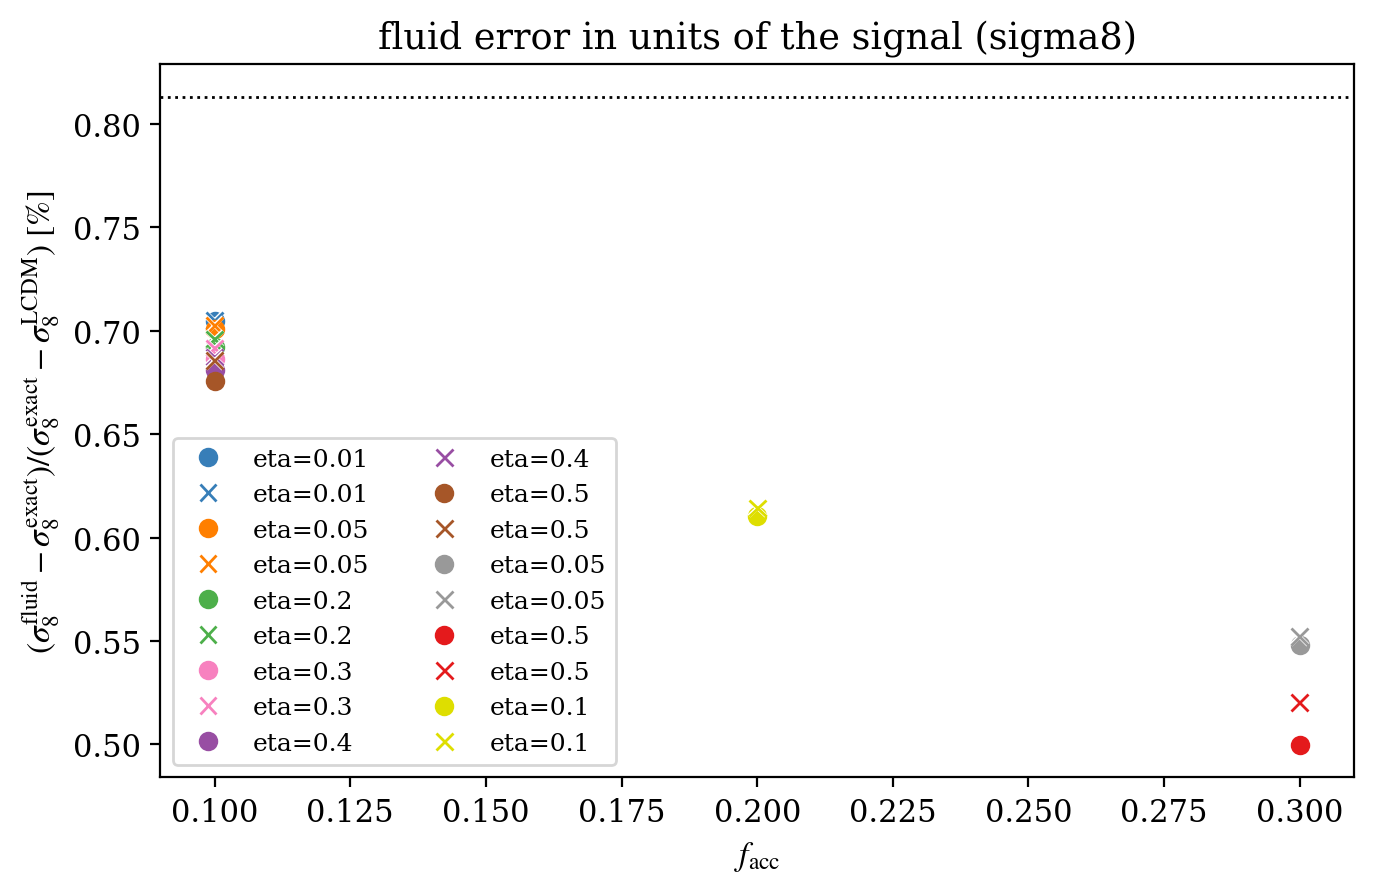

In [16]:
### Plot results for sigma8 error-to-signal, with the same verdicts as the k-dependent plot above.

from matplotlib import patheffects as pe

fig, ax = plt.subplots(figsize=(7.0, 4.6))

# ax.axhspan(-100*EPS_TARGET, 100*EPS_TARGET, color='0.9',
#            label=r'$\pm${:.0f}% target'.format(100*EPS_TARGET))
for color, (f_acc, eta) in zip(qual_colors, CORNERS):
    sigma8_exact = runs[('exact', f_acc, eta)]['sigma8']
    sigma8_fluid = runs[('fluid', f_acc, eta)]['sigma8']
    sigma8_signal = sigma8_exact - sigma8_lcdm
    ax.plot([f_acc], sigma8_exact, 'o', color=color, label='eta={:g}'.format(eta))
    ax.plot([f_acc], sigma8_fluid, 'x', color=color, label='eta={:g}'.format(eta), path_effects=[pe.withStroke(linewidth=1.5, foreground='w')])
ax.axhline(0.81316, color='k', ls=':', lw=1)
ax.set_xlabel(r'$f_\mathrm{acc}$'); ax.set_ylabel(r'$(\sigma_8^\mathrm{fluid}-\sigma_8^\mathrm{exact})/(\sigma_8^\mathrm{exact}-\sigma_8^\mathrm{LCDM})\ [\%]$')
ax.set_title('fluid error in units of the signal (sigma8)')
# ax.set_ylim(-15, 15); ax.grid(alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

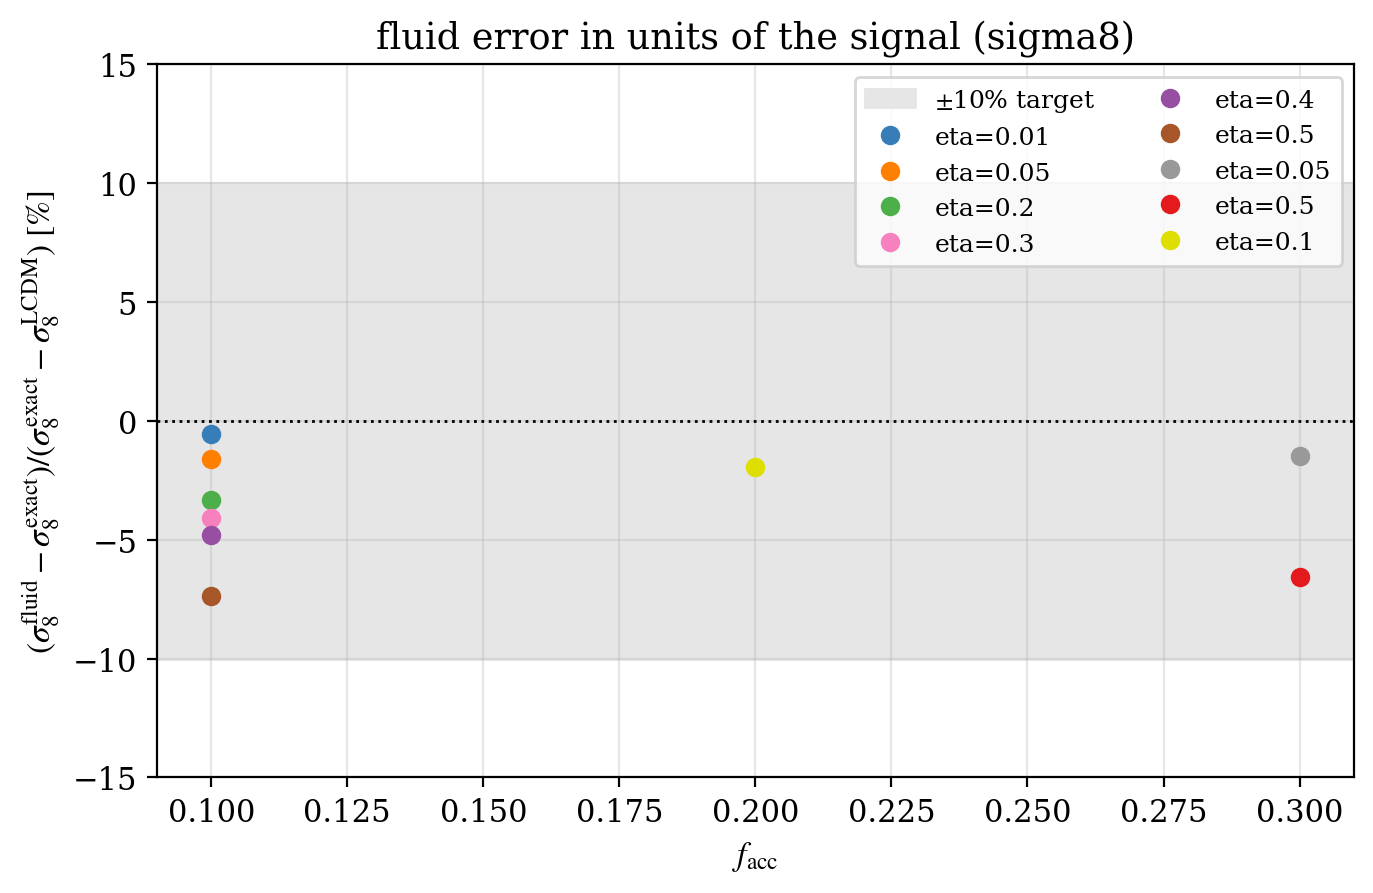

In [17]:
### Plot results for sigma8 error-to-signal, with the same verdicts as the k-dependent plot above.

fig, ax = plt.subplots(figsize=(7.0, 4.6))

ax.axhspan(-100*EPS_TARGET, 100*EPS_TARGET, color='0.9',
           label=r'$\pm${:.0f}% target'.format(100*EPS_TARGET))
for color, (f_acc, eta) in zip(qual_colors, CORNERS):
    sigma8_exact = runs[('exact', f_acc, eta)]['sigma8']
    sigma8_fluid = runs[('fluid', f_acc, eta)]['sigma8']
    sigma8_signal = sigma8_exact - sigma8_lcdm
    ratio = (sigma8_fluid - sigma8_exact)/sigma8_signal if abs(sigma8_signal) > 1e-6 else np.nan
    ax.plot([f_acc], [100*ratio], 'o', color=color, label='eta={:g}'.format(eta))
ax.axhline(0.0, color='k', ls=':', lw=1)
ax.set_xlabel(r'$f_\mathrm{acc}$'); ax.set_ylabel(r'$(\sigma_8^\mathrm{fluid}-\sigma_8^\mathrm{exact})/(\sigma_8^\mathrm{exact}-\sigma_8^\mathrm{LCDM})\ [\%]$')
ax.set_title('fluid error in units of the signal (sigma8)')
ax.set_ylim(-15, 15); ax.grid(alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

## 4. Degeneracy check: does the fluid error mimic a parameter shift?

A small error that is *orthogonal* to the (f, eta) signal directions adds noise; one that is
*parallel* to them biases the posterior even if tiny. Build crude finite-difference templates
for d lnP / d f and d lnP / d eta from the exact corner runs (central differences across the
corner grid -- order-of-magnitude only, the grid is wide), then least-squares fit the center
corner's fluid error `ln(P_fluid/P_exact)` on the data window. The fitted (delta_f, delta_eta)
is the parameter bias the fluid would induce at that point; compare to plausible posterior
widths before trusting MCMC results built on this fluid.

center corner f=0.2, eta=0.1:
  equivalent parameter bias:  delta_f = +0.0257,  delta_eta = -0.2911
  fraction of fluid error explained by (f, eta) shifts on K_DATA: 94%
  -> high explained fraction = the error is DEGENERATE with the signal (bias, not noise);
     compare delta_f/delta_eta to expected posterior widths before running MCMC on this fluid.


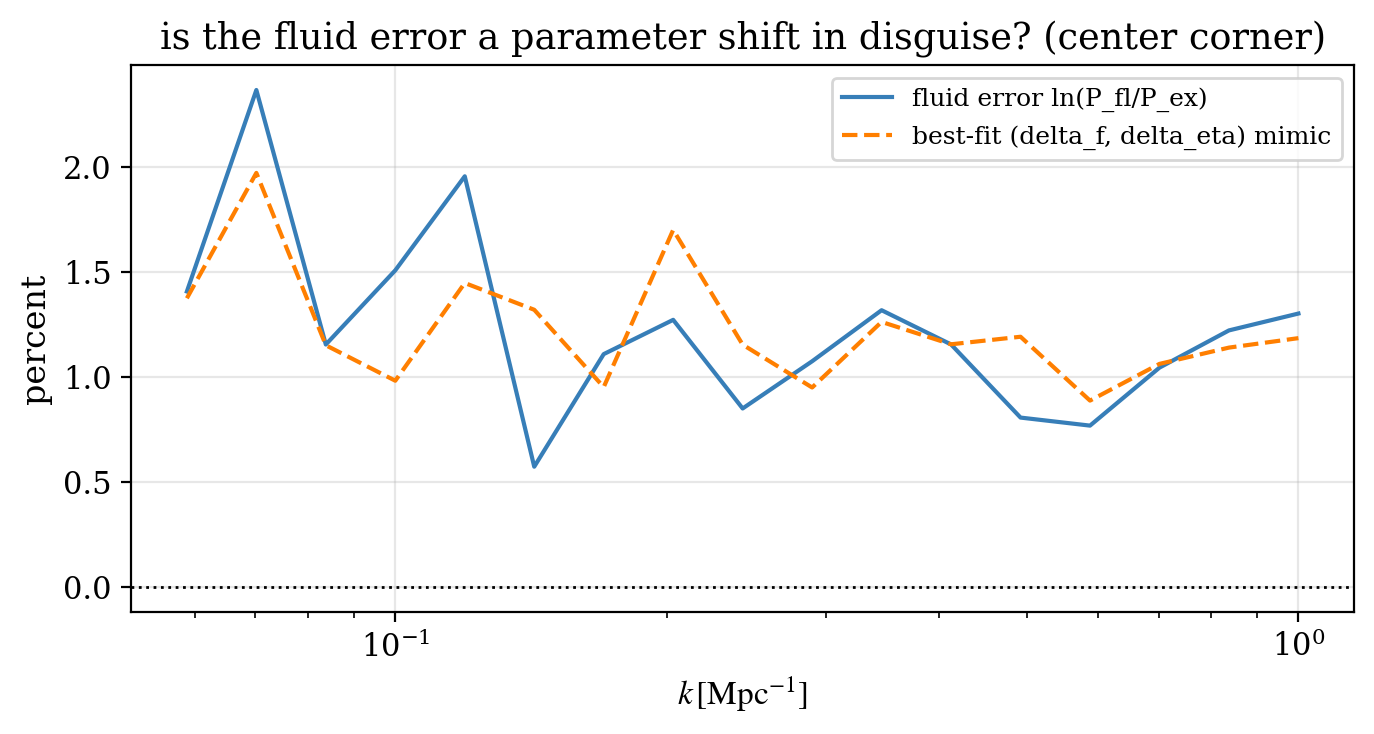

In [18]:
ln_pk = {corner: np.log(runs[('exact',) + corner]['pk']) for corner in CORNERS}

template_f = (ln_pk[(0.3, 0.05)] + ln_pk[(0.3, 0.5)]
              - ln_pk[(0.1, 0.05)] - ln_pk[(0.1, 0.5)]) / (2*(0.3 - 0.1))
template_eta = (ln_pk[(0.1, 0.5)] + ln_pk[(0.3, 0.5)]
                - ln_pk[(0.1, 0.05)] - ln_pk[(0.3, 0.05)]) / (2*(0.5 - 0.05))

center_corner = (0.2, 0.1)
fluid_error_ln = np.log(runs[('fluid',) + center_corner]['pk']
                        / runs[('exact',) + center_corner]['pk'])

design_matrix = np.vstack([template_f[k_data_mask], template_eta[k_data_mask]]).T
target_vector = fluid_error_ln[k_data_mask]
bias_solution, residual_ss, _, _ = np.linalg.lstsq(design_matrix, target_vector, rcond=None)
fitted_component = design_matrix @ bias_solution
explained_fraction = 1.0 - (np.sum((target_vector - fitted_component)**2)
                            / np.sum(target_vector**2))

print('center corner f={:g}, eta={:g}:'.format(*center_corner))
print('  equivalent parameter bias:  delta_f = {:+.4f},  delta_eta = {:+.4f}'.format(*bias_solution))
print('  fraction of fluid error explained by (f, eta) shifts on K_DATA: {:.0%}'.format(explained_fraction))
print('  -> high explained fraction = the error is DEGENERATE with the signal (bias, not noise);')
print('     compare delta_f/delta_eta to expected posterior widths before running MCMC on this fluid.')

fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.plot(K_PK[k_data_mask], 100*target_vector, color=qual_colors[0], label='fluid error ln(P_fl/P_ex)')
ax.plot(K_PK[k_data_mask], 100*fitted_component, color=qual_colors[1], ls='--',
        label='best-fit (delta_f, delta_eta) mimic')
ax.axhline(0.0, color='k', ls=':', lw=1)
ax.set_xscale('log'); ax.grid(alpha=0.3)
ax.set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$'); ax.set_ylabel('percent')
ax.set_title('is the fluid error a parameter shift in disguise? (center corner)')
ax.legend()
plt.tight_layout(); plt.show()

## Verdict (fill in after running)

- **Shapes / error-to-signal**: which corners PASS (max|eps| < 10% on K_DATA), which are
  broadband-only (median fine, max blown by spike/dip pairs), which FAIL outright?
- **sigma8 level**: consistent with the k-resolved verdict? If sigma8 passes where the
  k-resolved max fails, the fluid is usable for S8-band likelihoods but not full-shape.
- **Degeneracy**: explained fraction and (delta_f, delta_eta) -- if the bias is a large
  fraction of plausible posterior widths, the paper-style justification does NOT carry over
  to our regime regardless of the eps numbers.
- Cross-checks worth one rerun each: TRIGGER (delayed switch-on should collapse the low-k
  dip if it is a switch-during-production transient) and SHEAR = 'no' (corrected dynamical
  shear; only expected to matter for the k > 0.5 phase-shift structure).

## Warm-corner branch diagnostic (pink: f=0.3, eta=0.5)

Decides where the flat +5-8% P(k) excess of the adiabatic+dynamical-shear fluid accrues:

- **Branch A (switch transient):** the ratio delta_fluid/delta_exact shows a STEP at the
  abundance-gate switch (same a for all k) and stays flat after. Prime mechanism: the
  delta_p discontinuity at handoff -- exact delta_p/delta_rho sits at ~0.55 cg2 at x >> 1,
  the adiabatic fluid imposes cg2 instantly (third panel shows it directly). Fixes:
  Pi-equation rerun (`switch_on_eq_delta_p_acc`), ceff2 relaxation blending, or the
  saturated-T(x) closure.
- **Branch B (secular):** the ratio ramps through the fluid epoch -- deep-free-streaming
  under-damping; fixes go through Landau-rate sigma damping + measured kick-linear cvis2.

Second figure: k ~ 0.8-1 crash forensics -- fluid sigma trajectory vs exact, plus the
decay-source stiffness ratio Lambda/max(aH, k sqrt(ca2)) (the perturbations_acc_stiff_ratio
quantity, rebuilt from the background table). Exact reference at q=1001: a SHAPE diagnostic,
not 1%-metrology.

In [33]:
# --- Warm-corner branch diagnostic: runs + extraction (pink: f=0.3, eta=0.5) ---
# Config PINNED here (the currently-validated fluid): adiabatic ceff2, dynamical
# shear, abundance trigger 1. Deliberately NOT inherited from notebook globals.
SERIES_TRIGGER, SERIES_SHEAR = 10.0, 'no'
PINK_F, PINK_ETA = 0.3, 0.5
K_PROBE = [0.05, 0.2, 0.8, 1.0]          # sorted; CLASS returns k_output in this order
Q_SERIES = 1001                          # shape diagnostic, not 1%-metrology

def _match_key(sample_dict, want):
    if want in sample_dict:
        return want
    stripped = want.replace(' ', '').lower()
    for key in sample_dict:
        if key.replace(' ', '').lower().startswith(stripped):
            return key
    raise KeyError('{!r} not found; keys: {}'.format(want, sorted(sample_dict.keys())))

def _match_first(sample_dict, candidates):
    for want in candidates:
        try:
            return _match_key(sample_dict, want)
        except KeyError:
            continue
    return None

def extract_series(params, k_probe_list, tag):
    """CLASS run with k_output_values; returns background table + per-k tau-series
    for the daughter (delta, theta, shear, and delta_p/delta_rho when available)."""
    cache_file = os.path.join(CACHE_DIR, '{}_series_{}.pkl'.format(CACHE_TAG, tag))
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as fh:
            out = pickle.load(fh)
        print('[cache] series {}'.format(tag))
        return out
    print('[run  ] series {} ...'.format(tag), flush=True)
    t_start = time.time()
    p = dict(params)
    p['k_output_values'] = ', '.join('{:.5g}'.format(k) for k in k_probe_list)
    cosmo = Class(); cosmo.set(p); cosmo.compute()
    perturbation_dicts = cosmo.get_perturbations()['scalar']
    background = cosmo.get_background()
    out = {'background': {kk: np.array(vv) for kk, vv in background.items()}, 'series': {}}
    for k_value, d in zip(k_probe_list, perturbation_dicts):
        rec = {'a': np.array(d[_match_key(d, 'a')])}
        rec['delta_d'] = np.array(d[_match_key(d, 'delta_ncdm[1]')])
        rec['theta_d'] = np.array(d[_match_key(d, 'theta_ncdm[1]')])
        rec['shear_d'] = np.array(d[_match_key(d, 'shear_ncdm[1]')])
        dpr_key = _match_first(d, ['delta_p_over_delta_rho_ncdm[1]', 'cs2_ncdm[1]', 'dpr'])
        rec['dpr'] = np.array(d[dpr_key]) if dpr_key is not None else None
        out['series'][k_value] = rec
    cosmo.struct_cleanup(); cosmo.empty()
    with open(cache_file, 'wb') as fh:
        pickle.dump(out, fh)
    print('[done ] series {}  {:.0f} s'.format(tag, time.time() - t_start))
    return out

exact_run = extract_series(
    accdm_params(PINK_F, PINK_ETA, Q_SERIES),
    K_PROBE, 'exact_pink_q{}'.format(Q_SERIES))

fluid_p = accdm_params(PINK_F, PINK_ETA, Q_SERIES)   # same pre-switch resolution
fluid_p['ncdm_fluid_approximation'] = 2
fluid_p['ncdm_fluid_trigger_rho_accDM_over_rho_dcdm'] = SERIES_TRIGGER
fluid_p['switch_off_shear_acc'] = SERIES_SHEAR
fluid_p['ncdm_ceff2_mode'] = 0
fluid_p['ncdm_ceff2_fs_amp'] = 0.0
fluid_run = extract_series(
    fluid_p, K_PROBE,
    'fluid_pink_q{}_t{:g}_shear{}'.format(Q_SERIES, SERIES_TRIGGER, SERIES_SHEAR))

# switch epoch: abundance gate rho_daughter/rho_parent = SERIES_TRIGGER (same a for all k)
bg = exact_run['background']
a_bg = 1.0/(1.0 + bg[_match_key(bg, 'z')])
rho_parent_bg = bg[_match_key(bg, '(.)rho_acc_cdm')]
rho_daughter_bg = bg[_match_key(bg, '(.)rho_ncdm[1]')]
abundance_ratio = rho_daughter_bg/np.where(rho_parent_bg > 0, rho_parent_bg, np.nan)
crossed = np.where(abundance_ratio >= SERIES_TRIGGER)[0]
a_switch = float(a_bg[crossed[0]]) if crossed.size else float('nan')
print('abundance-gate switch epoch: a_switch = {:.4f} (trigger {})'.format(a_switch, SERIES_TRIGGER))


[cache] series exact_pink_q1001
[cache] series fluid_pink_q1001_t10_shearno
abundance-gate switch epoch: a_switch = 0.1835 (trigger 10.0)


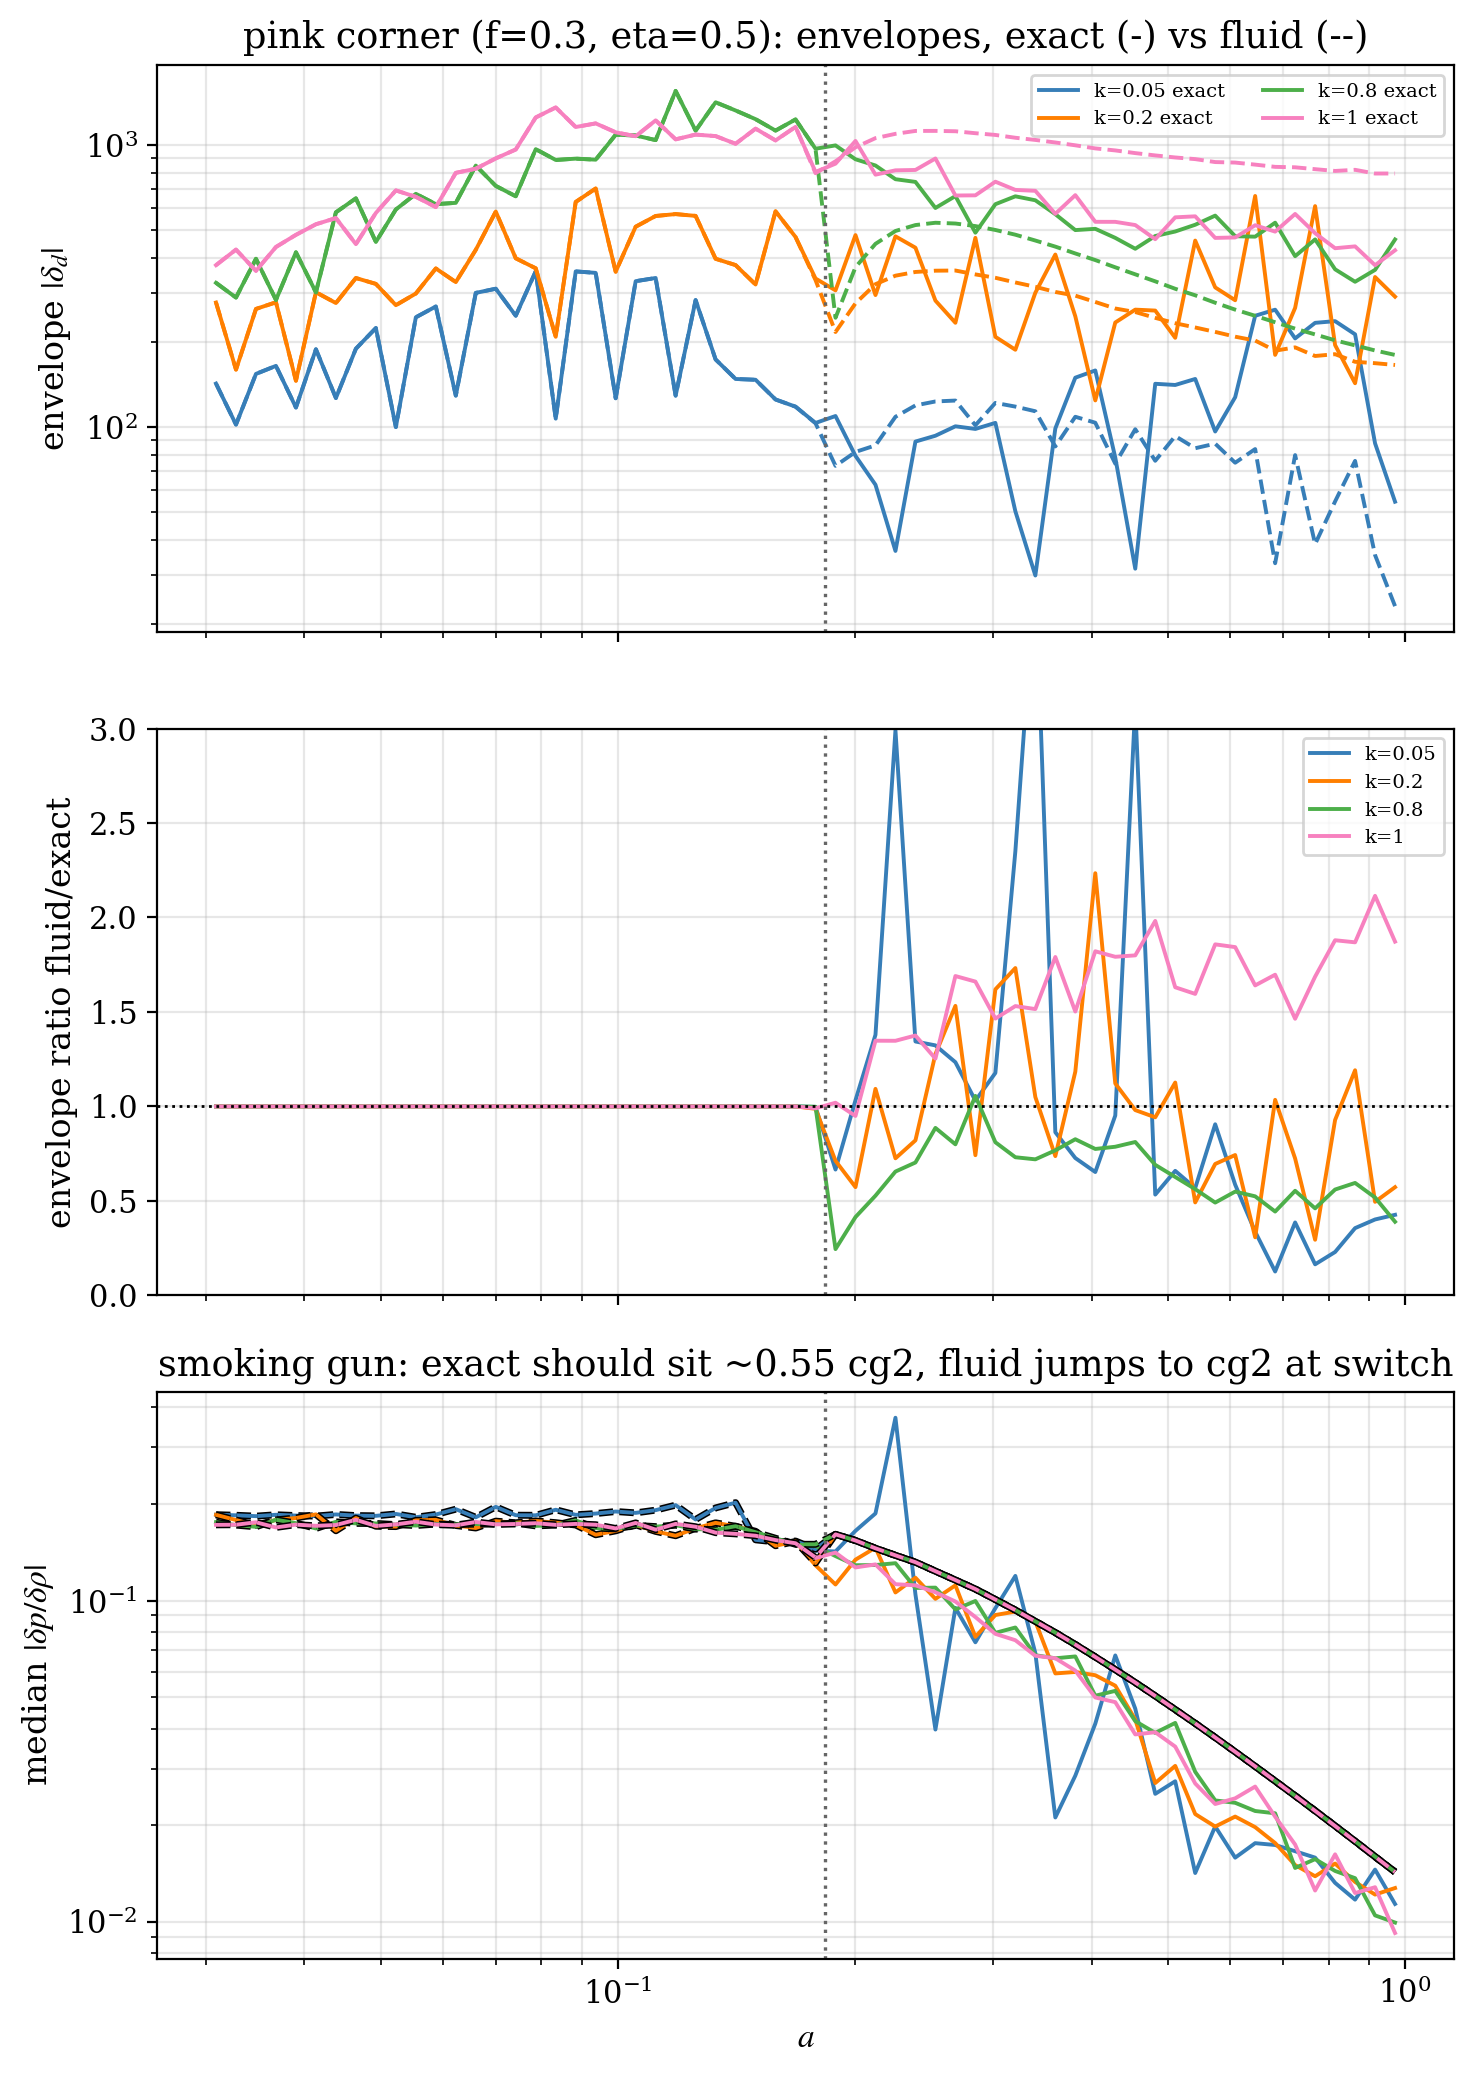

step-vs-secular (envelope ratio fluid/exact):
  k      just after switch   late (a>0.5)   verdict
  0.05         1.32              0.39       RAMP (Branch B)
   0.2         0.82              0.71       RAMP (Branch B)
   0.8         0.66              0.54       RAMP (Branch B)
     1         1.35              1.77       RAMP (Branch B)


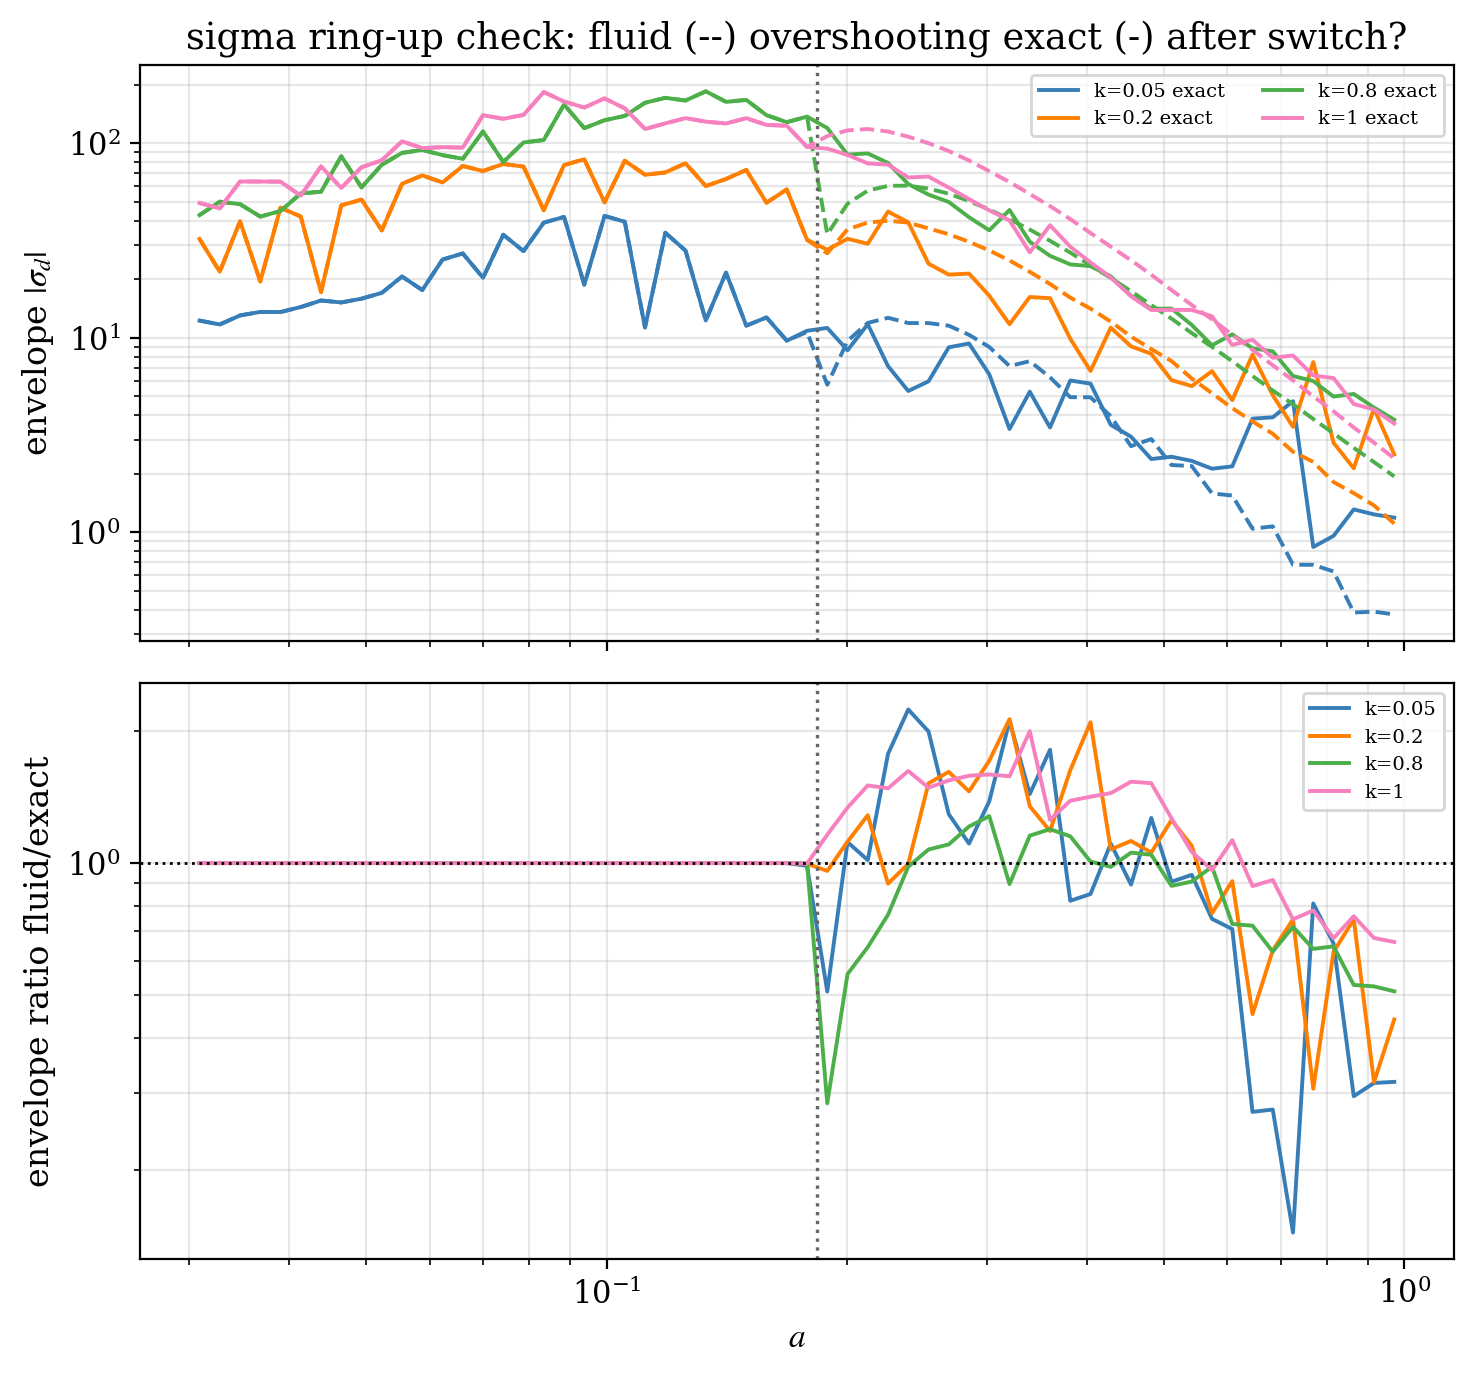

sigma read-off: ratio >> 1 right after switch decaying slowly = under-damped
sigma transient (candidate for the k~0.8 P(k) crash and part of the flat offset);
ratio ~ 1 throughout = sigma is fine and the offset lives in delta/theta dynamics.
(decay-source stiffness already RULED OUT: Lambda/max(aH, k sqrt(ca2)) ~ 1e-2 << 1
for the whole fluid epoch -- v1 figure.)


In [34]:
# --- Branch read-off v2: ENVELOPE-based comparison (pointwise ratios of two
# oscillating series with different phases are unreadable -- v1 lesson). The
# envelope (per-log-a-bin high quantile of |y|) is phase-blind; its fluid/exact
# ratio answers step-vs-secular directly. Note |delta| ~ 1e5-1e6 at k ~ 1, a -> 1
# is NORMAL (R=1 units), not a blow-up.
A_ZOOM = (0.03, 1.0)   # pre-switch is verified bit-identical; zoom on the fluid epoch

def log_envelope(a_values, y_values, n_bins=60, a_lo=A_ZOOM[0], a_hi=A_ZOOM[1],
                 quantile=0.9, min_per_bin=3):
    """Per-log-a-bin quantile of |y|: a phase-blind oscillation envelope."""
    edges = np.logspace(np.log10(a_lo), np.log10(a_hi), n_bins + 1)
    centers = np.sqrt(edges[:-1]*edges[1:])
    envelope = np.full(n_bins, np.nan)
    for i in range(n_bins):
        in_bin = (a_values >= edges[i]) & (a_values < edges[i+1]) & np.isfinite(y_values)
        if np.count_nonzero(in_bin) >= min_per_bin:
            envelope[i] = np.quantile(np.abs(y_values[in_bin]), quantile)
    return centers, envelope

qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf']
step_rows = []

fig, (ax_env, ax_ratio, ax_dpr) = plt.subplots(3, 1, figsize=(7.5, 10.5), sharex=True)
for color, k_value in zip(qual_colors, K_PROBE):
    exact_s = exact_run['series'][k_value]
    fluid_s = fluid_run['series'][k_value]
    a_env, exact_env = log_envelope(exact_s['a'], exact_s['delta_d'])
    _, fluid_env = log_envelope(fluid_s['a'], fluid_s['delta_d'])
    ax_env.loglog(a_env, exact_env, '-', color=color, lw=1.4, label='k={:g} exact'.format(k_value))
    ax_env.loglog(a_env, fluid_env, '--', color=color, lw=1.4)
    envelope_ratio = fluid_env/exact_env
    ax_ratio.semilogx(a_env, envelope_ratio, '-', color=color, lw=1.4,
                      label='k={:g}'.format(k_value))
    # step-vs-secular metric: ratio just after switch vs at late times
    early_window = (a_env >= a_switch) & (a_env <= 1.5*a_switch)
    late_window = (a_env >= 0.5)
    early_ratio = np.nanmedian(envelope_ratio[early_window])
    late_ratio = np.nanmedian(envelope_ratio[late_window])
    step_rows.append((k_value, early_ratio, late_ratio))
    # delta_p/delta_rho: median (not envelope) -- it is a ratio already
    if exact_s['dpr'] is not None and fluid_s['dpr'] is not None:
        _, exact_dpr = log_envelope(exact_s['a'], exact_s['dpr'], quantile=0.5)
        _, fluid_dpr = log_envelope(fluid_s['a'], fluid_s['dpr'], quantile=0.5)
        ax_dpr.loglog(a_env, exact_dpr, '-', color=color, lw=1.4)
        ax_dpr.loglog(a_env, fluid_dpr, '--', color=color, lw=1.4, path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])
for ax in (ax_env, ax_ratio, ax_dpr):
    ax.axvline(a_switch, color='0.4', ls=':', lw=1.2)
    ax.grid(True, which='both', alpha=0.3)
ax_env.set_ylabel(r'envelope $|\delta_d|$'); ax_env.legend(fontsize=7, ncol=2)
ax_env.set_title('pink corner (f={}, eta={}): envelopes, exact (-) vs fluid (--)'
                 .format(PINK_F, PINK_ETA))
ax_ratio.axhline(1.0, color='k', ls=':', lw=1)
ax_ratio.set_ylim(0, 3)
ax_ratio.set_ylabel('envelope ratio fluid/exact'); ax_ratio.legend(fontsize=7)
ax_dpr.set_ylabel(r'median $|\delta p/\delta\rho|$'); ax_dpr.set_xlabel(r'$a$')
ax_dpr.set_title('smoking gun: exact should sit ~0.55 cg2, fluid jumps to cg2 at switch')
plt.tight_layout(); plt.show()

print('step-vs-secular (envelope ratio fluid/exact):')
print('  k      just after switch   late (a>0.5)   verdict')
for k_value, early_ratio, late_ratio in step_rows:
    if np.isfinite(early_ratio) and np.isfinite(late_ratio):
        verdict = ('STEP (Branch A)' if abs(late_ratio - early_ratio) < 0.3*abs(early_ratio - 1.0)
                   else 'RAMP (Branch B)' if abs(late_ratio - 1.0) > abs(early_ratio - 1.0)
                   else 'mixed/decaying transient')
    else:
        verdict = 'insufficient bins'
    print('  {:4g}       {:6.2f}            {:6.2f}       {}'.format(
        k_value, early_ratio, late_ratio, verdict))

# --- sigma ring-up quantified + stiffness recap ---
fig, (ax_sig, ax_sigr) = plt.subplots(2, 1, figsize=(7.5, 7.0), sharex=True)
for color, k_value in zip(qual_colors, K_PROBE):
    exact_s = exact_run['series'][k_value]
    fluid_s = fluid_run['series'][k_value]
    a_env, exact_sig_env = log_envelope(exact_s['a'], exact_s['shear_d'])
    _, fluid_sig_env = log_envelope(fluid_s['a'], fluid_s['shear_d'])
    ax_sig.loglog(a_env, exact_sig_env, '-', color=color, lw=1.4,
                  label='k={:g} exact'.format(k_value))
    ax_sig.loglog(a_env, fluid_sig_env, '--', color=color, lw=1.4)
    ax_sigr.semilogx(a_env, fluid_sig_env/exact_sig_env, '-', color=color, lw=1.4,
                     label='k={:g}'.format(k_value))
for ax in (ax_sig, ax_sigr):
    ax.axvline(a_switch, color='0.4', ls=':', lw=1.2)
    ax.grid(True, which='both', alpha=0.3)
ax_sig.set_ylabel(r'envelope $|\sigma_d|$'); ax_sig.legend(fontsize=7, ncol=2)
ax_sig.set_title('sigma ring-up check: fluid (--) overshooting exact (-) after switch?')
ax_sigr.axhline(1.0, color='k', ls=':', lw=1)
ax_sigr.set_yscale('log')
ax_sigr.set_ylabel('envelope ratio fluid/exact'); ax_sigr.set_xlabel(r'$a$')
ax_sigr.legend(fontsize=7)
plt.tight_layout(); plt.show()

print('sigma read-off: ratio >> 1 right after switch decaying slowly = under-damped')
print('sigma transient (candidate for the k~0.8 P(k) crash and part of the flat offset);')
print('ratio ~ 1 throughout = sigma is fine and the offset lives in delta/theta dynamics.')
print('(decay-source stiffness already RULED OUT: Lambda/max(aH, k sqrt(ca2)) ~ 1e-2 << 1')
print('for the whole fluid epoch -- v1 figure.)')
